In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


df = pd.read_csv("Datasets/final_dataset_4moods.csv")


audio_cols = ['danceability', 'tempo', 'acousticness',
              'speechiness', 'liveness', 'instrumentalness', 'duration_ms', 'key', 'mode', 'loudness']


genre_cols = [col for col in df.columns if col.startswith("playlist_subgenre_")]


features = df[audio_cols + genre_cols]
target = df['mood']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)

# Modeli eğit
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

# Rapor
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        Calm       0.56      0.18      0.28       201
   Energetic       0.66      0.80      0.73      1901
         Sad       0.65      0.52      0.58       391
    Stressed       0.67      0.58      0.62      1398

    accuracy                           0.66      3891
   macro avg       0.64      0.52      0.55      3891
weighted avg       0.66      0.66      0.65      3891



RANDOM FOREST CLASS WEIGHT

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report



features = df[audio_cols + genre_cols]
target = df['mood']


X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)


model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        Calm       0.55      0.14      0.23       201
   Energetic       0.65      0.83      0.73      1901
         Sad       0.68      0.54      0.60       391
    Stressed       0.71      0.56      0.62      1398

    accuracy                           0.67      3891
   macro avg       0.65      0.52      0.55      3891
weighted avg       0.67      0.67      0.65      3891



FINDING BEST PARAMETER (GRID SEARCH)

In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}


rf = RandomForestClassifier(random_state=42, class_weight='balanced')


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,  
    scoring='f1_weighted',  
    n_jobs=-1,  
    verbose=2  
)


grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)

print("Best Parameters Found:", grid_search.best_params_)
print(classification_report(y_test, y_pred))



Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters Found: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

        Calm       0.39      0.29      0.33       201
   Energetic       0.69      0.73      0.71      1901
         Sad       0.54      0.66      0.59       391
    Stressed       0.66      0.59      0.62      1398

    accuracy                           0.65      3891
   macro avg       0.57      0.57      0.57      3891
weighted avg       0.65      0.65      0.65      3891



FINDING BEST PARAMETERS (RANDOMIZED SEARCH)

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30, 
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)


print("Best Parameters Found:", random_search.best_params_)


best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)


print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 307}
              precision    recall  f1-score   support

        Calm       0.43      0.27      0.33       201
   Energetic       0.69      0.77      0.73      1901
         Sad       0.56      0.63      0.59       391
    Stressed       0.68      0.59      0.63      1398

    accuracy                           0.67      3891
   macro avg       0.59      0.57      0.57      3891
weighted avg       0.66      0.67      0.66      3891



SMOTE OVERSAMPLING 

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from collections import Counter


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


best_params = {
    'n_estimators': 307,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 2
}


best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)

best_model.fit(X_resampled, y_resampled)


y_pred = best_model.predict(X_test)


print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))


              precision    recall  f1-score   support

        Calm       0.29      0.44      0.35       201
   Energetic       0.73      0.70      0.71      1901
         Sad       0.52      0.61      0.56       391
    Stressed       0.66      0.62      0.64      1398

    accuracy                           0.65      3891
   macro avg       0.55      0.59      0.57      3891
weighted avg       0.66      0.65      0.65      3891

Counter({'Energetic': 7605, 'Stressed': 5589, 'Sad': 1562, 'Calm': 806})
Counter({'Sad': 7605, 'Energetic': 7605, 'Stressed': 7605, 'Calm': 7605})


ADASYN OVERSAMPLING

In [11]:
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)

best_params = {
    'n_estimators': 307,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 2
}

best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)


best_model.fit(X_resampled, y_resampled)


y_pred = best_model.predict(X_test)


print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))

              precision    recall  f1-score   support

        Calm       0.28      0.42      0.34       201
   Energetic       0.72      0.72      0.72      1901
         Sad       0.54      0.64      0.59       391
    Stressed       0.68      0.60      0.64      1398

    accuracy                           0.65      3891
   macro avg       0.56      0.60      0.57      3891
weighted avg       0.67      0.65      0.66      3891

Counter({'Energetic': 7605, 'Stressed': 5589, 'Sad': 1562, 'Calm': 806})
Counter({'Energetic': 7605, 'Calm': 7457, 'Sad': 7102, 'Stressed': 6163})


SMOTTEENN OVERSAMPLING

In [13]:
from imblearn.combine import SMOTEENN


smoteenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smoteenn.fit_resample(X_train, y_train)


best_params = {
    'n_estimators': 307,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 2
}


best_model = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42
)


best_model.fit(X_resampled, y_resampled)

y_pred = best_model.predict(X_test)


print(classification_report(y_test, y_pred))
print(Counter(y_train))
print(Counter(y_resampled))

              precision    recall  f1-score   support

        Calm       0.17      0.58      0.27       201
   Energetic       0.76      0.31      0.44      1901
         Sad       0.40      0.61      0.48       391
    Stressed       0.52      0.69      0.59      1398

    accuracy                           0.49      3891
   macro avg       0.46      0.55      0.45      3891
weighted avg       0.61      0.49      0.49      3891

Counter({'Energetic': 7605, 'Stressed': 5589, 'Sad': 1562, 'Calm': 806})
Counter({'Calm': 2359, 'Sad': 2041, 'Stressed': 1025, 'Energetic': 407})


FUTURE IMPORTANCE 

              precision    recall  f1-score   support

        Calm       0.56      0.18      0.28       201
   Energetic       0.66      0.80      0.73      1901
         Sad       0.65      0.52      0.58       391
    Stressed       0.67      0.58      0.62      1398

    accuracy                           0.66      3891
   macro avg       0.64      0.52      0.55      3891
weighted avg       0.66      0.66      0.65      3891



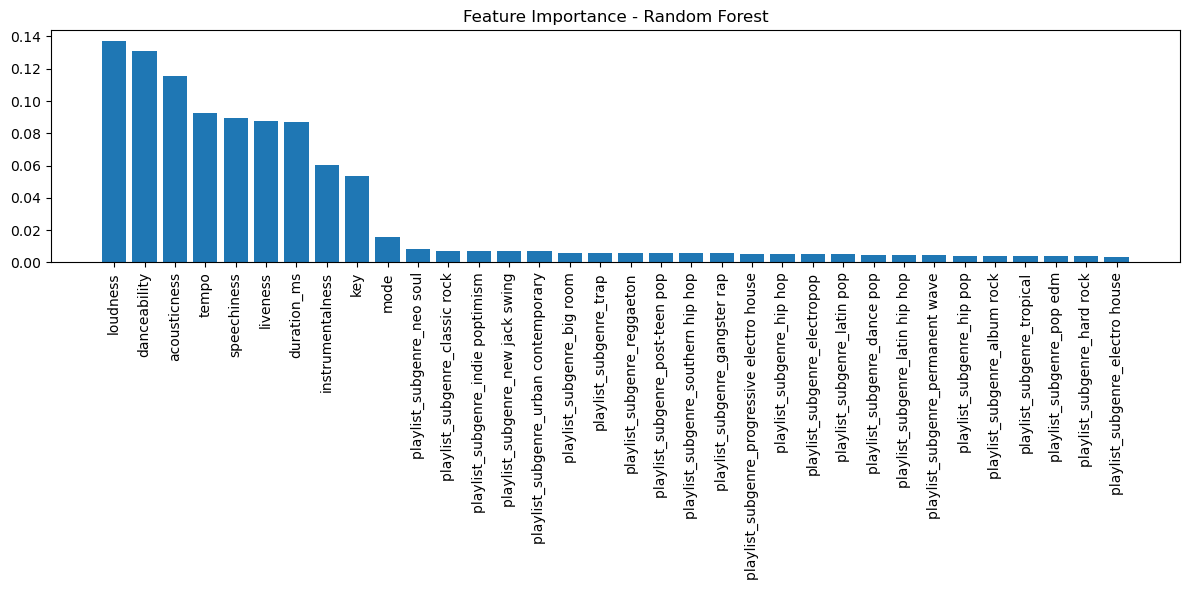

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np



model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print(classification_report(y_test, y_pred))


importances = model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]


plt.figure(figsize=(12, 6))
plt.title("Feature Importance - Random Forest")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()


XGBOOST MODEL

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:39:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 Classification Report (XGBoost):
              precision    recall  f1-score   support

        Calm       0.44      0.23      0.30       201
   Energetic       0.68      0.77      0.72      1901
         Sad       0.60      0.52      0.56       391
    Stressed       0.65      0.60      0.63      1398

    accuracy                           0.66      3891
   macro avg       0.60      0.53      0.55      3891
weighted avg       0.65      0.66      0.65      3891



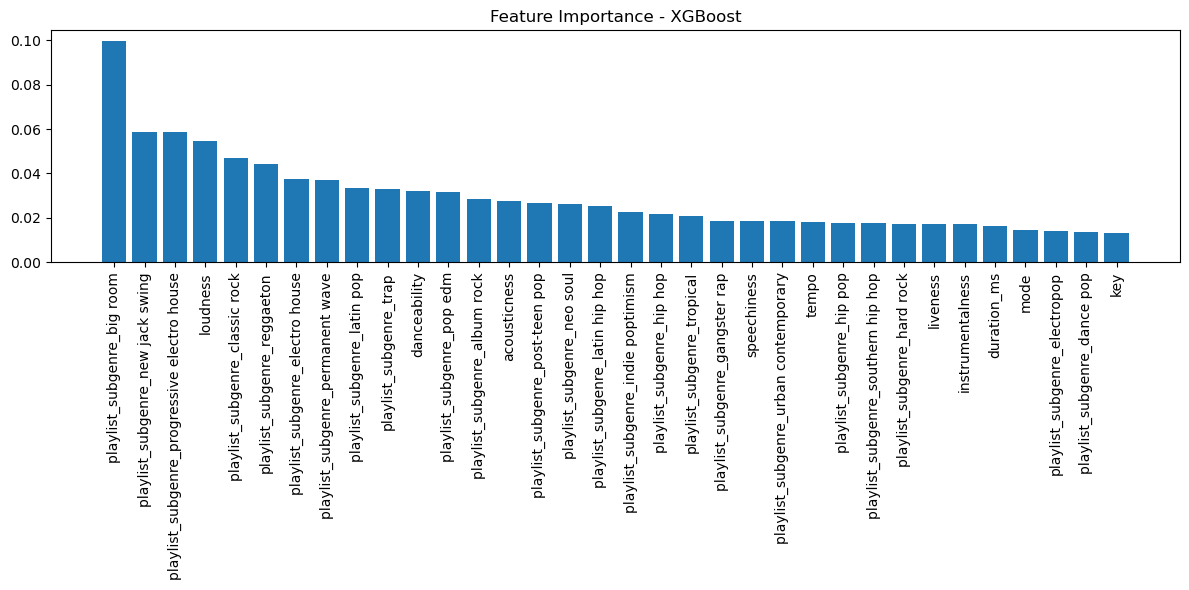

In [2]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)


xgb_model.fit(X_train, y_train_encoded)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("📊 Classification Report (XGBoost):")
print(classification_report(y_test, y_pred))


importances = xgb_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]


plt.figure(figsize=(12, 6))
plt.title("Feature Importance - XGBoost")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()




CLASS WEIGHT  XGBOOST MODEL

In [3]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)


xgb_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print(classification_report(y_test, y_pred))

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:40:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

        Calm       0.31      0.42      0.35       201
   Energetic       0.73      0.65      0.69      1901
         Sad       0.51      0.62      0.56       391
    Stressed       0.63      0.65      0.64      1398

    accuracy                           0.64      3891
   macro avg       0.54      0.58      0.56      3891
weighted avg       0.65      0.64      0.64      3891



FINDING BEST PARAMETERS

In [4]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight



sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)


param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.5]
}


random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=60,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=1,  
    random_state=42
)



random_search.fit(X_train, y_train_encoded, sample_weight=sample_weights)


print("✅ Best Parameters Found:")
print(random_search.best_params_)

from sklearn.metrics import classification_report
y_pred_encoded = random_search.best_estimator_.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report (XGBoost - Tuned):")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 60 candidates, totalling 180 fits


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:40:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   0.8s


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:40:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   1.0s


...

[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   1.3s


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:44:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   1.4s


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:44:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Best Parameters Found:
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.6}

📊 Classification Report (XGBoost - Tuned):
              precision    recall  f1-score   support

        Calm       0.50      0.29      0.37       201
   Energetic       0.70      0.74      0.72      1901
         Sad       0.61      0.62      0.61       391
    Stressed       0.66      0.64      0.65      1398

    accuracy                           0.67      3891
   macro avg       0.62      0.57      0.59      3891
weighted avg       0.67      0.67      0.67      3891



In [5]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)


param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2, 0.5]
}


random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=100,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=1,  
    random_state=42
)



random_search.fit(X_train, y_train_encoded, sample_weight=sample_weights)


print("✅ Best Parameters Found:")
print(random_search.best_params_)

from sklearn.metrics import classification_report
y_pred_encoded = random_search.best_estimator_.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report (XGBoost - Tuned):")
print(classification_report(y_test, y_pred))
acc = accuracy_score(y_test, y_pred)
print(f"✅ Mean Accuracy on Test Set: {round(acc, 4)}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:41:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   0.7s


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:41:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   0.8s


...

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:50:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=300, subsample=1.0; total time=   1.2s


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:50:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Best Parameters Found:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

📊 Classification Report (XGBoost - Tuned):
              precision    recall  f1-score   support

        Calm       0.42      0.35      0.38       201
   Energetic       0.72      0.71      0.71      1901
         Sad       0.57      0.63      0.60       391
    Stressed       0.64      0.66      0.65      1398

    accuracy                           0.66      3891
   macro avg       0.59      0.59      0.59      3891
weighted avg       0.66      0.66      0.66      3891



NameError: name 'accuracy_score' is not defined

GRIDSEARCH İLE PARAMETRE ARAMA

In [14]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',         
    num_class=len(le.classes_),         
    eval_metric='mlogloss',             
    use_label_encoder=False,
    random_state=42
)


param_grid = {
    'n_estimators': [100, 200],             
    'max_depth': [3, 5, 7],                
    'learning_rate': [0.05, 0.1],           
    'subsample': [0.8, 1.0],              
    'colsample_bytree': [0.8, 1.0],         
    'min_child_weight': [1, 3],            
    'gamma': [0, 0.1]                      
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=1  
)


grid_search.fit(X_train, y_train_encoded, sample_weight=sample_weights)


best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"\n✅ Best Parameters Found: {best_params}")

y_pred_encoded = best_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


acc = accuracy_score(y_test, y_pred)
print(f"\n📊 Classification Report (XGBoost - GridSearchCV):")
print(classification_report(y_test, y_pred))

print(f"✅ Mean Accuracy on Test Set: {round(acc, 4)}")


Fitting 3 folds for each of 192 candidates, totalling 576 fits


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:52:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.2s


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:52:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.3s


...

[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=200, subsample=1.0; total time=   1.5s


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:03:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.1, max_depth=7, min_child_weight=3, n_estimators=200, subsample=1.0; total time=   1.5s


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:03:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Best Parameters Found: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}

📊 Classification Report (XGBoost - GridSearchCV):
              precision    recall  f1-score   support

        Calm       0.36      0.43      0.39       201
   Energetic       0.74      0.67      0.71      1901
         Sad       0.55      0.68      0.61       391
    Stressed       0.65      0.67      0.66      1398

    accuracy                           0.66      3891
   macro avg       0.58      0.61      0.59      3891
weighted avg       0.67      0.66      0.66      3891

✅ Mean Accuracy on Test Set: 0.6602


In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter


smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train_encoded)

print("📊 Resampled class distribution after SMOTE:")
print(Counter(y_smote))


for label, count in Counter(y_smote).items():
    print(f"{le.inverse_transform([label])[0]}: {count}")


sample_weights_smote = compute_sample_weight(class_weight='balanced', y=y_smote)


best_params = {
    'n_estimators': 300,
    'max_depth': 10,
    'learning_rate': 0.1,
    'subsample': 0.6,
    'gamma': 0.2,
    'colsample_bytree': 0.8,
    'min_child_weight': 3
}

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    **best_params
)


model.fit(X_smote, y_smote, sample_weight=sample_weights_smote)


y_pred_encoded = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report (XGBoost + SMOTE):")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy with SMOTE: {round(acc, 4)}")


📊 Resampled class distribution after SMOTE:
Counter({2: 7605, 1: 7605, 3: 7605, 0: 7605})
Sad: 7605
Energetic: 7605
Stressed: 7605
Calm: 7605


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:23:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + SMOTE):
              precision    recall  f1-score   support

        Calm       0.36      0.29      0.32       201
   Energetic       0.70      0.74      0.72      1901
         Sad       0.58      0.57      0.57       391
    Stressed       0.66      0.62      0.64      1398

    accuracy                           0.66      3891
   macro avg       0.57      0.56      0.56      3891
weighted avg       0.65      0.66      0.65      3891

✅ Accuracy with SMOTE: 0.6566


In [2]:
from imblearn.over_sampling import ADASYN
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train_encoded)


from collections import Counter



sample_weights = compute_sample_weight(class_weight='balanced', y=y_resampled)

best_params = {
    'n_estimators': 200,
    'max_depth': 10,
    'learning_rate': 0.2,
    'subsample': 1.0,
    'gamma': 0,
    'colsample_bytree': 0.6,
    'min_child_weight': 1
}

model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    **best_params
)


model.fit(X_resampled, y_resampled, sample_weight=sample_weights)

y_pred_encoded = model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print("\n📊 Classification Report (XGBoost + ADASYN):")
print(classification_report(y_test, y_pred))




print("📊 Resampled class distribution after SMOTE:")
print(Counter(y_resampled))


for label, count in Counter(y_resampled).items():
    print(f"{le.inverse_transform([label])[0]}: {count}")

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:05:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + ADASYN):
              precision    recall  f1-score   support

        Calm       0.32      0.27      0.29       201
   Energetic       0.69      0.73      0.71      1901
         Sad       0.59      0.57      0.58       391
    Stressed       0.65      0.62      0.63      1398

    accuracy                           0.65      3891
   macro avg       0.56      0.55      0.55      3891
weighted avg       0.65      0.65      0.65      3891



NameError: name 'accuracy_score' is not defined

LOGISTIC REGRESSION 

📊 Classification Report (Logistic Regression):
              precision    recall  f1-score   support

        Calm       0.00      0.00      0.00       201
   Energetic       0.00      0.00      0.00      1901
         Sad       0.10      1.00      0.18       391
    Stressed       0.00      0.00      0.00      1398

    accuracy                           0.10      3891
   macro avg       0.03      0.25      0.05      3891
weighted avg       0.01      0.10      0.02      3891



/Users/yeliz/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yeliz/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yeliz/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


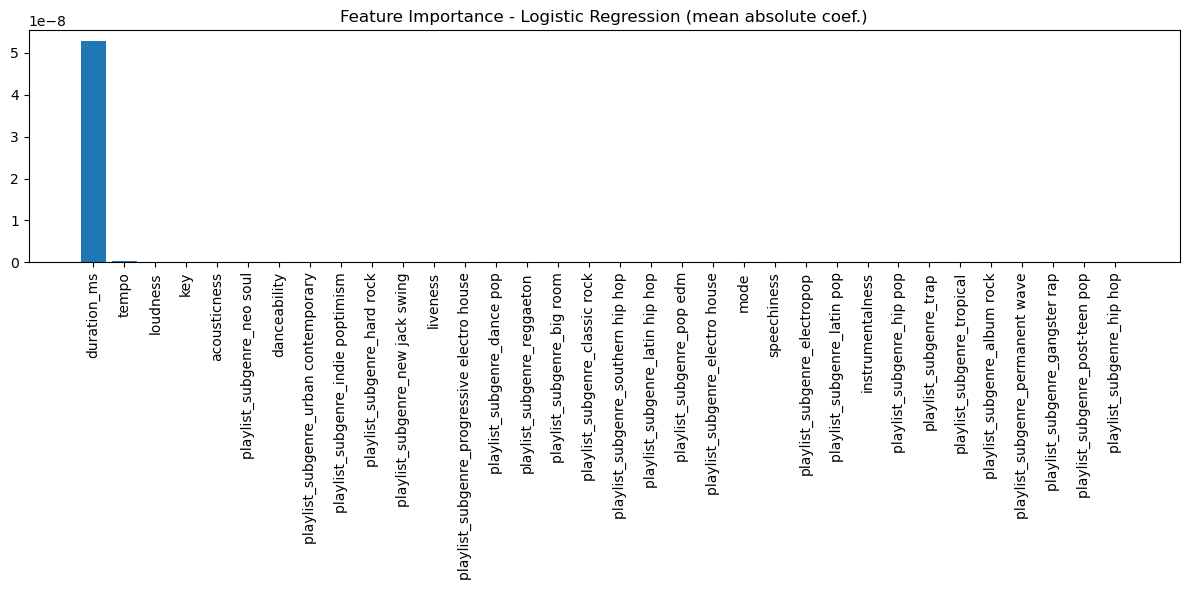

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


log_model = LogisticRegression(
    class_weight='balanced',    
    max_iter=1000,               
    solver='lbfgs',              
    multi_class='multinomial',
    random_state=42
)


log_model.fit(X_train, y_train_encoded)


y_pred_encoded = log_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print("📊 Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred))


import numpy as np
import matplotlib.pyplot as plt

coefs = np.abs(log_model.coef_).mean(axis=0)
indices = np.argsort(coefs)[::-1]
feature_names = X_train.columns

plt.figure(figsize=(12, 6))
plt.title("Feature Importance - Logistic Regression (mean absolute coef.)")
plt.bar(range(len(coefs)), coefs[indices])
plt.xticks(range(len(coefs)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()


CATBOOST DENEMESİ

0:	learn: 1.3075253	total: 9.77ms	remaining: 2.92s
100:	learn: 0.7568367	total: 373ms	remaining: 735ms
200:	learn: 0.6957202	total: 755ms	remaining: 372ms
299:	learn: 0.6496370	total: 1.13s	remaining: 0us
📊 Classification Report (CatBoost):
              precision    recall  f1-score   support

        Calm       0.40      0.16      0.23       201
   Energetic       0.66      0.78      0.72      1901
         Sad       0.59      0.51      0.55       391
    Stressed       0.66      0.58      0.62      1398

    accuracy                           0.65      3891
   macro avg       0.58      0.51      0.53      3891
weighted avg       0.64      0.65      0.64      3891



/var/folders/8w/9vgx4cp514zb47hglblm7xcm0000gn/T/ipykernel_2460/3562506752.py:46: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
/Users/yeliz/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


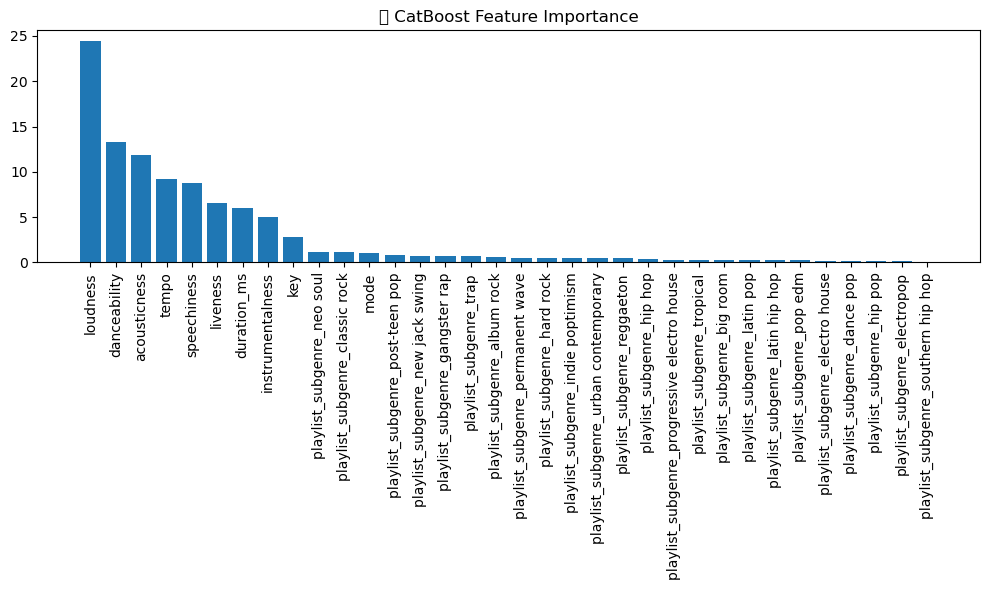

In [34]:
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import numpy as np

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)

cat_model.fit(X_train, y_train_encoded)


y_pred_encoded = cat_model.predict(X_test)
y_pred_encoded = y_pred_encoded.flatten()  
y_pred = le.inverse_transform(y_pred_encoded)


print("📊 Classification Report (CatBoost):")
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt


feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]


importances = cat_model.get_feature_importance()
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.title("🔍 CatBoost Feature Importance")
plt.tight_layout()
plt.show()



PREPARE PRAMETERS

In [35]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import numpy as np

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


cat = CatBoostClassifier(
    loss_function='MultiClass',
    verbose=0,
    random_seed=42
)

param_dist = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}


NO CLASS WEİGHT 

In [19]:
print("🔁 RandomizedSearch WITHOUT class weights...\n")

random_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train_encoded)

print("✅ Best Params (No class weight):", random_search.best_params_)

# Tahmin ve rapor
y_pred = random_search.best_estimator_.predict(X_test)
y_pred = y_pred.flatten()
y_pred_labels = le.inverse_transform(y_pred)

print("\n📊 Classification Report (No class weight):")
print(classification_report(y_test, y_pred_labels))


🔁 RandomizedSearch WITHOUT class weights...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Best Params (No class weight): {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 8}

📊 Classification Report (No class weight):
              precision    recall  f1-score   support

        Calm       0.42      0.18      0.25       201
   Energetic       0.67      0.79      0.72      1901
         Sad       0.63      0.56      0.59       391
    Stressed       0.67      0.58      0.62      1398

    accuracy                           0.66      3891
   macro avg       0.60      0.53      0.55      3891
weighted avg       0.65      0.66      0.65      3891



WITH CLASS WEIGHT

In [36]:
print("\n🔁 RandomizedSearch WITH class weights (via sample_weight)...\n")

random_search_weighted = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_weighted.fit(X_train, y_train_encoded, sample_weight=sample_weights)

print("✅ Best Params (With class weight):", random_search_weighted.best_params_)

# Tahmin ve rapor
y_pred_weighted = random_search_weighted.best_estimator_.predict(X_test)
y_pred_weighted = y_pred_weighted.flatten()
y_pred_weighted_labels = le.inverse_transform(y_pred_weighted)

print("\n📊 Classification Report (With class weight):")
print(classification_report(y_test, y_pred_weighted_labels))



🔁 RandomizedSearch WITH class weights (via sample_weight)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Best Params (With class weight): {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 8}

📊 Classification Report (With class weight):
              precision    recall  f1-score   support

        Calm       0.31      0.50      0.38       201
   Energetic       0.74      0.64      0.68      1901
         Sad       0.50      0.65      0.57       391
    Stressed       0.63      0.65      0.64      1398

    accuracy                           0.63      3891
   macro avg       0.55      0.61      0.57      3891
weighted avg       0.66      0.63      0.64      3891



In [23]:
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from collections import Counter
import numpy as np


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train_encoded)

class_counts = Counter(y_resampled)
print("📊 Class distribution after SMOTE (encoded):")
for label, count in class_counts.items():
    mood_name = le.inverse_transform([label])[0]
    print(f"{mood_name}: {count} samples")


sample_weights = compute_sample_weight(class_weight='balanced', y=y_resampled)


cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)

cat_model.fit(X_resampled, y_resampled, sample_weight=sample_weights)


y_pred_encoded = cat_model.predict(X_test).flatten()
y_pred = le.inverse_transform(y_pred_encoded)


print("\n📊 Classification Report (CatBoost + SMOTE + Class Weight + Best Params):")
print(classification_report(y_test, y_pred))


📊 Class distribution after SMOTE (encoded):
Sad: 7605 samples
Energetic: 7605 samples
Stressed: 7605 samples
Calm: 7605 samples
0:	learn: 1.3153993	total: 50.5ms	remaining: 15.1s
100:	learn: 0.7177196	total: 5.85s	remaining: 11.5s
[CV] END depth=8, iterations=100, l2_leaf_reg=5, learning_rate=0.1; total time=  10.4s
[CV] END depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.01; total time=   7.6s
[CV] END depth=4, iterations=100, l2_leaf_reg=9, learning_rate=0.01; total time=   3.3s
[CV] END depth=4, iterations=100, l2_leaf_reg=9, learning_rate=0.01; total time=   2.4s
[CV] END depth=8, iterations=300, l2_leaf_reg=3, learning_rate=0.1; total time=  32.8s
[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   8.5s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   6.6s
[CV] END depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.01; total time=   7.0s
[CV] END depth=8, iterations=200, l2_leaf_reg=3, learning_rate=0.1;

In [26]:
from catboost import CatBoostClassifier
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from collections import Counter
import numpy as np


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train_encoded)


class_counts = Counter(y_resampled)
print("📊 Class distribution after ADASYN (encoded):")
for label, count in class_counts.items():
    mood_name = le.inverse_transform([label])[0]
    print(f"{mood_name}: {count} samples")


sample_weights = compute_sample_weight(class_weight='balanced', y=y_resampled)


cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    verbose=100,
    random_seed=42
)


cat_model.fit(X_resampled, y_resampled, sample_weight=sample_weights)


y_pred_encoded = cat_model.predict(X_test).flatten()
y_pred = le.inverse_transform(y_pred_encoded)


print("\n📊 Classification Report (CatBoost + ADASYN + Class Weight + Best Params):")
print(classification_report(y_test, y_pred))


📊 Class distribution after ADASYN (encoded):
Sad: 7102 samples
Energetic: 7605 samples
Stressed: 6163 samples
Calm: 7457 samples
0:	learn: 1.3173728	total: 14.1ms	remaining: 4.2s
100:	learn: 0.7247449	total: 1.44s	remaining: 2.84s
200:	learn: 0.6095775	total: 3.24s	remaining: 1.6s
299:	learn: 0.5320972	total: 6.83s	remaining: 0us

📊 Classification Report (CatBoost + ADASYN + Class Weight + Best Params):
              precision    recall  f1-score   support

        Calm       0.29      0.38      0.33       201
   Energetic       0.73      0.67      0.70      1901
         Sad       0.53      0.58      0.55       391
    Stressed       0.64      0.66      0.65      1398

    accuracy                           0.64      3891
   macro avg       0.55      0.58      0.56      3891
weighted avg       0.65      0.64      0.65      3891



In [27]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import numpy as np


top_features = [
    'loudness', 'danceability', 'acousticness', 'tempo',
    'speechiness', 'liveness', 'duration_ms', 'instrumentalness', 'key'
]


X_train_top = X_train[top_features]
X_test_top = X_test[top_features]


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


cat = CatBoostClassifier(
    loss_function='MultiClass',
    verbose=0,
    random_seed=42
)


param_dist = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

print("\n🔁 RandomizedSearch WITH class weights (via sample_weight)...\n")

# Randomized Search
random_search_weighted = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_weighted.fit(X_train_top, y_train_encoded, sample_weight=sample_weights)


print("✅ Best Params (With class weight):", random_search_weighted.best_params_)

y_pred_weighted = random_search_weighted.best_estimator_.predict(X_test_top)
y_pred_weighted = y_pred_weighted.flatten()
y_pred_weighted_labels = le.inverse_transform(y_pred_weighted)


print("\n📊 Classification Report (CatBoost - Top 9 Features):")
print(classification_report(y_test, y_pred_weighted_labels))


🔁 RandomizedSearch WITH class weights (via sample_weight)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Best Params (With class weight): {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 8}

📊 Classification Report (CatBoost - Top 9 Features):
              precision    recall  f1-score   support

        Calm       0.29      0.47      0.36       201
   Energetic       0.71      0.60      0.65      1901
         Sad       0.48      0.65      0.56       391
    Stressed       0.60      0.61      0.61      1398

    accuracy                           0.60      3891
   macro avg       0.52      0.58      0.54      3891
weighted avg       0.63      0.60      0.61      3891

[CV] END depth=6, iterations=200, l2_leaf_reg=5, learning_rate=0.05; total time=   4.4s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=   3.7s
[CV] END depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.01; total time=   6.1s
[CV] END depth=8

ÖZELLİK BİRLEŞTİRME

In [37]:
df['rhythmic_energy'] = df['tempo'] * df['danceability']
df['acoustic_complexity'] = df['acousticness'] + df['instrumentalness'] + df['liveness']
df['speech_density'] = df['speechiness'] / (df['duration_ms'] / 1000)
df['intensity_balance'] = df['loudness'] / df['tempo']
df['electro_acoustic_ratio'] = df['acousticness'] / (df['instrumentalness'] + 1e-6)

In [38]:
new_features = [
    'danceability', 'loudness', 'tempo', 'speechiness', 'liveness',
    'acousticness', 'instrumentalness', 'duration_ms',
    'rhythmic_energy', 'acoustic_complexity', 'speech_density',
    'intensity_balance', 'electro_acoustic_ratio'
]


genre_cols = [col for col in df.columns if col.startswith("playlist_subgenre_")]
X = df[new_features + genre_cols]
y = df['mood']


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


XGBOOST 

In [31]:
import xgboost as xgb
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight


new_features = [
    'danceability', 'loudness', 'tempo', 'speechiness', 'liveness',
    'acousticness', 'instrumentalness', 'duration_ms',
    'rhythmic_energy', 'acoustic_complexity', 'speech_density',
    'intensity_balance', 'electro_acoustic_ratio'
]

genre_cols = [col for col in df.columns if col.startswith("playlist_subgenre_")]
X = df[new_features + genre_cols]
y = df['mood']


le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.model_selection import train_test_split
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# XGBoost Model (En iyi parametrelerle)
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    subsample=0.6,
    n_estimators=300,
    min_child_weight=3,
    max_depth=10,
    learning_rate=0.1,
    gamma=0.2,
    colsample_bytree=0.8
)


xgb_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("📊 Classification Report (XGBoost with Engineered Features):")
print(classification_report(le.inverse_transform(y_test_encoded), y_pred))


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:05:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 Classification Report (XGBoost with Engineered Features):
              precision    recall  f1-score   support

        Calm       0.38      0.33      0.35       201
   Energetic       0.69      0.71      0.70      1901
         Sad       0.58      0.59      0.58       391
    Stressed       0.64      0.63      0.64      1398

    accuracy                           0.65      3891
   macro avg       0.57      0.56      0.57      3891
weighted avg       0.65      0.65      0.65      3891



CATBOOST DENEMESİ

In [40]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report


new_features = [
    'danceability', 'loudness', 'tempo', 'speechiness', 'liveness',
    'acousticness', 'instrumentalness', 'duration_ms',
    'rhythmic_energy', 'acoustic_complexity', 'speech_density',
    'intensity_balance', 'electro_acoustic_ratio'
]


genre_cols = [col for col in df.columns if col.startswith("playlist_subgenre_")]
X = df[new_features + genre_cols]
y = df['mood']


le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

cat_model = CatBoostClassifier(
    learning_rate=0.1,
    l2_leaf_reg=3,
    iterations=300,
    depth=8,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100
)


cat_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)

# Tahmin
y_pred_encoded = cat_model.predict(X_test).flatten()
y_pred = le.inverse_transform(y_pred_encoded)

# Rapor
print("📊 Classification Report (CatBoost with Engineered Features):")
print(classification_report(le.inverse_transform(y_test_encoded), y_pred))


0:	learn: 1.3294402	total: 34.9ms	remaining: 10.4s
100:	learn: 0.7197993	total: 1.44s	remaining: 2.85s
200:	learn: 0.5648106	total: 2.88s	remaining: 1.42s
299:	learn: 0.4728896	total: 4.1s	remaining: 0us
📊 Classification Report (CatBoost with Engineered Features):
              precision    recall  f1-score   support

        Calm       0.31      0.50      0.38       201
   Energetic       0.74      0.65      0.69      1901
         Sad       0.52      0.66      0.58       391
    Stressed       0.64      0.65      0.65      1398

    accuracy                           0.64      3891
   macro avg       0.55      0.61      0.58      3891
weighted avg       0.66      0.64      0.65      3891

[CV] END depth=8, iterations=200, l2_leaf_reg=1, learning_rate=0.01; total time=  14.9s
[CV] END depth=4, iterations=100, l2_leaf_reg=9, learning_rate=0.01; total time=   2.2s
[CV] END depth=8, iterations=200, l2_leaf_reg=3, learning_rate=0.1; total time=  16.7s
[CV] END depth=8, iterations=200, l2_

In [21]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import pandas as pd
import numpy as np


df = pd.read_csv("final_dataset.csv")

audio_cols = ['danceability', 'tempo', 'acousticness', 'speechiness', 'liveness',
              'instrumentalness', 'duration_ms', 'key', 'mode', 'loudness']
genre_cols = [col for col in df.columns if col.startswith("playlist_subgenre_")]

X = df[audio_cols + genre_cols]
y = df['mood']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("🎯 Orijinal train dağılımı:", Counter(y_train_encoded))


adasyn = ADASYN(sampling_strategy={0: 3000, 2: 3000}, random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train_encoded)
print("🔼 ADASYN sonrası dağılım:", Counter(y_adasyn))


mask_enn = np.isin(y_adasyn, [1, 3])
X_enn_part = X_adasyn[mask_enn]
y_enn_part = y_adasyn[mask_enn]

enn = EditedNearestNeighbours()
X_enn_resampled, y_enn_resampled = enn.fit_resample(X_enn_part, y_enn_part)


X_rest = X_adasyn[~mask_enn]
y_rest = y_adasyn[~mask_enn]

X_final = np.vstack((X_enn_resampled, X_rest))
y_final = np.concatenate((y_enn_resampled, y_rest))

print("🧮 Final sınıf dağılımı:", Counter(y_final))


🎯 Orijinal train dağılımı: Counter({1: 7605, 3: 5589, 2: 1562, 0: 806})
🔼 ADASYN sonrası dağılım: Counter({1: 7605, 3: 5589, 2: 3103, 0: 2974})
🧮 Final sınıf dağılımı: Counter({3: 5589, 2: 3103, 0: 2974, 1: 1655})


In [13]:
import numpy as np
print(np.unique(y_train_encoded, return_counts=True))


(array([0, 1, 2, 3]), array([ 806, 7605, 1562, 5589]))


In [18]:
print(le.classes_)  # ['calm', 'energetic', 'sad', 'stressed'] gibi



['Calm' 'Energetic' 'Sad' 'Stressed']


YENİ SINIFLARI XGBOOST EĞİTME

In [22]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import numpy as np


sample_weights = compute_sample_weight(class_weight='balanced', y=y_final)


xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_final)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    # ✅ Best Params
    subsample=1.0,
    n_estimators=200,
    min_child_weight=1,
    max_depth=10,
    learning_rate=0.2,
    gamma=0,
    colsample_bytree=0.6
)


xgb_model.fit(X_final, y_final, sample_weight=sample_weights)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("\n📊 Classification Report (XGBoost + Sampling + Class Weights):")
print(classification_report(y_test, y_pred))


from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Mean Accuracy Score: {accuracy:.4f}")

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:35:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + Sampling + Class Weights):
              precision    recall  f1-score   support

        Calm       0.34      0.46      0.39       201
   Energetic       0.83      0.34      0.48      1901
         Sad       0.54      0.63      0.58       391
    Stressed       0.51      0.86      0.64      1398

    accuracy                           0.56      3891
   macro avg       0.55      0.57      0.52      3891
weighted avg       0.66      0.56      0.54      3891


✅ Mean Accuracy Score: 0.5636


NEW SAMPLİNG TRY

In [23]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import pandas as pd
import numpy as np


print("🎯 Orijinal train dağılımı:", Counter(y_train_encoded))


adasyn = ADASYN(sampling_strategy={0: 5000, 2: 5000}, random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train_encoded)
print("🔼 ADASYN sonrası dağılım:", Counter(y_adasyn))


mask_rus = np.isin(y_adasyn, [1, 3])
X_rus_part = X_adasyn[mask_rus]
y_rus_part = y_adasyn[mask_rus]

rus = RandomUnderSampler(
    sampling_strategy={1: 5000, 3: 5000},  # 1: energetic, 3: stressed
    random_state=42
)

X_rus_resampled, y_rus_resampled = rus.fit_resample(X_rus_part, y_rus_part)


X_rest = X_adasyn[~mask_rus]
y_rest = y_adasyn[~mask_rus]

X_final = np.vstack((X_rus_resampled, X_rest))
y_final = np.concatenate((y_rus_resampled, y_rest))

print("🧮 Final sınıf dağılımı:", Counter(y_final))


🎯 Orijinal train dağılımı: Counter({1: 7605, 3: 5589, 2: 1562, 0: 806})
🔼 ADASYN sonrası dağılım: Counter({1: 7605, 3: 5589, 0: 5288, 2: 4508})
🧮 Final sınıf dağılımı: Counter({0: 5288, 1: 5000, 3: 5000, 2: 4508})


In [24]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import numpy as np


sample_weights = compute_sample_weight(class_weight='balanced', y=y_final)

# XGBoost modeli (en iyi parametrelerle)
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_final)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    # ✅ Best Params
    subsample=1.0,
    n_estimators=200,
    min_child_weight=1,
    max_depth=10,
    learning_rate=0.2,
    gamma=0,
    colsample_bytree=0.6
)


xgb_model.fit(X_final, y_final, sample_weight=sample_weights)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print("\n📊 Classification Report (XGBoost + Sampling + Class Weights):")
print(classification_report(y_test, y_pred))


from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Mean Accuracy Score: {accuracy:.4f}")

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:39:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + Sampling + Class Weights):
              precision    recall  f1-score   support

        Calm       0.34      0.34      0.34       201
   Energetic       0.72      0.66      0.69      1901
         Sad       0.55      0.61      0.58       391
    Stressed       0.62      0.67      0.64      1398

    accuracy                           0.64      3891
   macro avg       0.56      0.57      0.56      3891
weighted avg       0.65      0.64      0.64      3891


✅ Mean Accuracy Score: 0.6415


In [25]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks




print("🎯 Orijinal train dağılımı:", Counter(y_train_encoded))

adasyn = ADASYN(sampling_strategy={0: 3000, 2: 3000}, random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train_encoded)
print("🔼 ADASYN sonrası dağılım:", Counter(y_adasyn))

mask_tomek = np.isin(y_adasyn, [1, 3])
X_tomek_part = X_adasyn[mask_tomek]
y_tomek_part = y_adasyn[mask_tomek]

tomek = TomekLinks()
X_tomek_res, y_tomek_res = tomek.fit_resample(X_tomek_part, y_tomek_part)

X_rest = X_adasyn[~mask_tomek]
y_rest = y_adasyn[~mask_tomek]


X_final = np.vstack((X_tomek_res, X_rest))
y_final = np.concatenate((y_tomek_res, y_rest))

print("✅ Final sınıf dağılımı:", Counter(y_final))


🎯 Orijinal train dağılımı: Counter({1: 7605, 3: 5589, 2: 1562, 0: 806})
🔼 ADASYN sonrası dağılım: Counter({1: 7605, 3: 5589, 2: 3103, 0: 2974})
✅ Final sınıf dağılımı: Counter({1: 5919, 3: 5589, 2: 3103, 0: 2974})


In [26]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import numpy as np


sample_weights = compute_sample_weight(class_weight='balanced', y=y_final)


xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_final)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    # ✅ Best Params
    subsample=1.0,
    n_estimators=200,
    min_child_weight=1,
    max_depth=10,
    learning_rate=0.2,
    gamma=0,
    colsample_bytree=0.6
)


xgb_model.fit(X_final, y_final, sample_weight=sample_weights)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print("\n📊 Classification Report (XGBoost + Sampling + Class Weights):")
print(classification_report(y_test, y_pred))


from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Mean Accuracy Score: {accuracy:.4f}")

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [14:43:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Classification Report (XGBoost + Sampling + Class Weights):
              precision    recall  f1-score   support

        Calm       0.34      0.32      0.33       201
   Energetic       0.72      0.67      0.69      1901
         Sad       0.56      0.59      0.58       391
    Stressed       0.61      0.67      0.64      1398

    accuracy                           0.64      3891
   macro avg       0.56      0.56      0.56      3891
weighted avg       0.64      0.64      0.64      3891


✅ Mean Accuracy Score: 0.6405


In [27]:


sample_weights = compute_sample_weight(class_weight='balanced', y=y_final)


rf = RandomForestClassifier(
    n_estimators=307,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=2,
    class_weight=None, 
    random_state=42
)


rf.fit(X_final, y_final, sample_weight=sample_weights)


y_pred = rf.predict(X_test)


print("✅ Mean Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("\n📊 Classification Report (Random Forest):")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))


/Users/yeliz/anaconda3/lib/python3.10/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


✅ Mean Accuracy: 0.640195322539193

📊 Classification Report (Random Forest):
              precision    recall  f1-score   support

        Calm       0.29      0.45      0.35       201
   Energetic       0.74      0.65      0.69      1901
         Sad       0.53      0.65      0.59       391
    Stressed       0.64      0.65      0.64      1398

    accuracy                           0.64      3891
   macro avg       0.55      0.60      0.57      3891
weighted avg       0.66      0.64      0.65      3891



In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb


df = pd.read_csv("final_dataset_4moods.csv")


audio_cols = ['danceability', 'tempo', 'acousticness',
              'speechiness', 'liveness', 'instrumentalness', 'duration_ms', 'key', 'mode', 'loudness']
genre_cols = [col for col in df.columns if col.startswith("playlist_subgenre_")]
features = df[audio_cols + genre_cols]
target = df['mood']


X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    subsample=1.0,
    n_estimators=200,
    min_child_weight=1,
    max_depth=10,
    learning_rate=0.2,
    gamma=0,
    colsample_bytree=0.6
)


xgb_model.fit(X_train, y_train_encoded, sample_weight=sample_weights)


y_pred_encoded = xgb_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)


print("✅ Mean Accuracy:", accuracy_score(y_test_encoded, y_pred_encoded))
print("\n📊 Classification Report (XGBoost):")
print(classification_report(y_test, y_pred))


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:15:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Mean Accuracy: 0.6705217167823182

📊 Classification Report (XGBoost):
              precision    recall  f1-score   support

        Calm       0.50      0.29      0.37       201
   Energetic       0.70      0.74      0.72      1901
         Sad       0.61      0.62      0.61       391
    Stressed       0.66      0.64      0.65      1398

    accuracy                           0.67      3891
   macro avg       0.62      0.57      0.59      3891
weighted avg       0.67      0.67      0.67      3891

